# Classifier Score Drift Across Focus-Crawl Segments

Sibling to `compare_classifier_scores.ipynb`. That notebook answers "is the focus crawl scoring higher than the baseline overall?". This one zooms into the **focus crawl only** and asks:

> **Do classifier scores drift over the lifetime of the focus crawl?**

Each segment of `CC-SUPPLEMENTAL-2026-22` was fetched at a different wall-clock time, encoded in the WARC path as a 14-digit `YYYYMMDDHHMMSS` token (e.g. `20260524073839`). `ccoa classify-warc` was run per segment and produced one CSV per segment in `data/gneissweb-science-top-10k/`, named `CC-SUPPLEMENTAL-2026-22_segment_<token>_scores.csv` (with a `.summary.csv` sidecar we ignore).

We load each per-segment CSV, summarise `prediction_score`, and plot the result against the segment datetime, oldest on the left. Under-sized segments (`n < MIN_RECORDS`) are dropped from the plots — they give noisy point estimates that masquerade as drift — but they remain in the per-segment table so the exclusion is auditable.

Plots produced:

1. **Mean ± SEM** — segment mean with standard-error bars (`std / √n`), so "is this mean shift real?" is visible at a glance. We deliberately do *not* plot the raw within-segment stdev: classifier scores are bimodal so the stdev is saturated near its max regardless of stability, and would just fill the axis.
2. **Median + percentile bands** — median with IQR (p25–p75) and outer (p10–p90) shaded bands. Shows where the body and tails of each segment actually sit; the heavy shading is itself informative because it makes the bimodality visible.
3. **High-confidence rate** — fraction of records with `score ≥ 0.5` and `score ≥ 0.9` per segment. Collapses the bimodal distribution into the action-relevant numbers ("what fraction will survive a downstream filter?").
4. **Mean + median side by side** — both as plain lines on the same axes. A quick consolidated view; divergence between the two lines flags tail-weight changes that aren't visible from either summary alone.

## Setup

```bash
uv sync --extra notebooks
```

In [1]:
from __future__ import annotations

import re
from datetime import datetime
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Resolve a data/ path that works whether Jupyter was launched from the repo
# root or from inside notebooks/ (same pattern as compare_classifier_scores.ipynb).
DATA_DIR = Path("data") if Path("data").exists() else Path("..") / "data"
SCORES_DIR = DATA_DIR / "gneissweb-science-top-10k"

FOCUS_NAME = "CC-SUPPLEMENTAL-2026-22"

print(f"SCORES_DIR: {SCORES_DIR} (exists={SCORES_DIR.exists()})")

SCORES_DIR: ../data/gneissweb-science-top-10k (exists=True)


## 1. Discover per-segment score files

Files are named `CC-SUPPLEMENTAL-2026-22_segment_<YYYYMMDDHHMMSS>_scores.csv`. We:

- glob the directory,
- skip the `.summary.csv` sidecars,
- extract the 14-digit datetime token with a regex anchored at start/end so we don't accidentally pick up resume parts (`_1m_scores__resume-2.csv`) or other unrelated files,
- parse the token with `strptime("%Y%m%d%H%M%S")`,
- sort chronologically.

If zero files match, we raise — "drift across no segments" isn't a meaningful question.

In [2]:
SEGMENT_RE = re.compile(rf"^{re.escape(FOCUS_NAME)}_segment_(\d{{14}})_scores\.csv$")

segments: list[tuple[datetime, Path]] = []
for path in SCORES_DIR.glob(f"{FOCUS_NAME}_segment_*_scores.csv"):
    if path.name.endswith(".summary.csv"):
        continue
    match = SEGMENT_RE.match(path.name)
    if not match:
        continue
    dt = datetime.strptime(match.group(1), "%Y%m%d%H%M%S")
    segments.append((dt, path))

segments.sort(key=lambda item: item[0])

if not segments:
    raise RuntimeError(
        f"No segment score files found in {SCORES_DIR} matching "
        f"{FOCUS_NAME}_segment_<YYYYMMDDHHMMSS>_scores.csv"
    )

print(f"Discovered {len(segments)} segment file(s) for {FOCUS_NAME}:")
for dt, path in segments:
    print(f"  {dt:%Y-%m-%d %H:%M:%S}  {path.name}")

Discovered 20 segment file(s) for CC-SUPPLEMENTAL-2026-22:
  2026-05-21 07:40:42  CC-SUPPLEMENTAL-2026-22_segment_20260521074042_scores.csv
  2026-05-22 07:20:19  CC-SUPPLEMENTAL-2026-22_segment_20260522072019_scores.csv
  2026-05-22 20:48:39  CC-SUPPLEMENTAL-2026-22_segment_20260522204839_scores.csv
  2026-05-23 07:11:17  CC-SUPPLEMENTAL-2026-22_segment_20260523071117_scores.csv
  2026-05-23 15:38:27  CC-SUPPLEMENTAL-2026-22_segment_20260523153827_scores.csv
  2026-05-23 23:53:50  CC-SUPPLEMENTAL-2026-22_segment_20260523235350_scores.csv
  2026-05-24 07:38:39  CC-SUPPLEMENTAL-2026-22_segment_20260524073839_scores.csv
  2026-05-24 15:05:44  CC-SUPPLEMENTAL-2026-22_segment_20260524150544_scores.csv
  2026-05-24 21:53:35  CC-SUPPLEMENTAL-2026-22_segment_20260524215335_scores.csv
  2026-05-25 04:13:49  CC-SUPPLEMENTAL-2026-22_segment_20260525041349_scores.csv
  2026-05-25 09:56:52  CC-SUPPLEMENTAL-2026-22_segment_20260525095652_scores.csv
  2026-05-25 15:32:27  CC-SUPPLEMENTAL-2026-22_seg

## 2. Per-segment summary statistics

Load only the `prediction_score` column from each CSV (matches the existing notebook's `load_scores`) and compute, per segment:

- `n`, `mean`, `std` — record count and central tendency / spread of the raw scores.
- `sem` = `std / √n` — standard error of the segment mean. Tells you how confidently you know the mean of that segment; the right thing to compare across segments for "is this drift real?".
- `p10`, `p25`, `median`, `p75`, `p90` — robust location plus inner (IQR) and outer (p10–p90) percentile bands. With a bimodal score distribution these say where the body and the tails of each segment actually sit, which a single number can't.
- `rate_ge_0p5`, `rate_ge_0p9` — fraction of records crossing two confidence thresholds. These collapse the bimodal score distribution into one interpretable number per threshold ("share of records the classifier is confident / very-confident are science").

One row per segment, indexed by segment datetime, sorted oldest-first.

In [3]:
def summarise_segment(csv_path: Path) -> dict[str, float]:
    """Return per-segment summary stats for the `prediction_score` column."""
    scores = pd.read_csv(csv_path, usecols=["prediction_score"])["prediction_score"].astype(float)
    n = len(scores)
    std = scores.std()
    return {
        "n": n,
        "mean": scores.mean(),
        "std": std,
        "sem": std / np.sqrt(n) if n > 0 else float("nan"),
        "p10": scores.quantile(0.10),
        "p25": scores.quantile(0.25),
        "median": scores.median(),
        "p75": scores.quantile(0.75),
        "p90": scores.quantile(0.90),
        "rate_ge_0p5": float((scores >= 0.5).mean()),
        "rate_ge_0p9": float((scores >= 0.9).mean()),
    }


rows = []
for dt, path in segments:
    stats = summarise_segment(path)
    stats["datetime"] = dt
    rows.append(stats)

segment_df = (
    pd.DataFrame(rows)
    .set_index("datetime")
    .sort_index()
    [["n", "mean", "std", "sem", "p10", "p25", "median", "p75", "p90", "rate_ge_0p5", "rate_ge_0p9"]]
)
segment_df.round(6)

,n,mean,std,sem,p10,p25,median,p75,p90,rate_ge_0p5,rate_ge_0p9
datetime,,,,,,,,,,,
2026-05-21 07:40:42,774,0.645442,0.424406,0.015255,0.001525,0.125491,0.961538,1.000008,1.000010,0.634367,0.547804
2026-05-22 07:20:19,100000,0.503106,0.446097,0.001411,0.000012,0.005312,0.494216,0.996504,1.000008,0.498790,0.393040
2026-05-22 20:48:39,100000,0.547554,0.443562,0.001403,0.000018,0.009292,0.715477,0.998142,1.000009,0.551660,0.428440
2026-05-23 07:11:17,100000,0.572431,0.422842,0.001337,0.001469,0.058675,0.734265,0.997574,1.000006,0.575540,0.419660
2026-05-23 15:38:27,100000,0.551677,0.426648,0.001349,0.000584,0.043649,0.675666,0.996329,1.000005,0.551630,0.402800
2026-05-23 23:53:50,100000,0.527371,0.429250,0.001357,0.000451,0.023967,0.604578,0.993502,0.999990,0.531660,0.376320
2026-05-24 07:38:39,100000,0.521990,0.428478,0.001355,0.000253,0.020752,0.589461,0.991732,0.999981,0.528160,0.365830
2026-05-24 15:05:44,100000,0.527064,0.428396,0.001355,0.000505,0.026120,0.608480,0.993531,0.999983,0.532300,0.366630
2026-05-24 21:53:35,100000,0.524074,0.431201,0.001364,0.000261,0.016711,0.611486,0.992160,0.999975,0.531870,0.370950


### Drop under-sized segments

The table above shows one segment with `n` well below the per-segment target (~100 000). With ~1 000 records or fewer, the mean/median estimates have wide sampling uncertainty and will visually dominate the drift plots as a fake "outlier". We filter to segments with `n >= 1000` before plotting; the full table above is left intact so the dropped segment(s) are still visible in the record.

In [4]:
MIN_RECORDS = 1000

dropped = segment_df[segment_df["n"] < MIN_RECORDS]
filtered_df = segment_df[segment_df["n"] >= MIN_RECORDS]

if len(dropped):
    print(f"Dropping {len(dropped)} segment(s) with n < {MIN_RECORDS}:")
    for ts, row in dropped.iterrows():
        print(f"  {ts:%Y-%m-%d %H:%M:%S}  n={int(row['n'])}")
else:
    print(f"No segments below n={MIN_RECORDS}; nothing dropped.")

print(f"Plotting {len(filtered_df)} segment(s).")

datetimes = (
    filtered_df.index.to_pydatetime()
    if hasattr(filtered_df.index, "to_pydatetime")
    else list(filtered_df.index)
)
means = filtered_df["mean"].to_numpy()
sems = filtered_df["sem"].to_numpy()
medians = filtered_df["median"].to_numpy()
p10 = filtered_df["p10"].to_numpy()
p25 = filtered_df["p25"].to_numpy()
p75 = filtered_df["p75"].to_numpy()
p90 = filtered_df["p90"].to_numpy()
rate_05 = filtered_df["rate_ge_0p5"].to_numpy()
rate_09 = filtered_df["rate_ge_0p9"].to_numpy()

Dropping 1 segment(s) with n < 1000:
  2026-05-21 07:40:42  n=774
Plotting 19 segment(s).


## 3. Mean ± SEM over time

Error bars are the **standard error of the mean** (`std / √n`), *not* the within-segment stdev. Why: classifier scores are bimodal (most pages near 0, a real-science tail near 1), so the raw stdev is essentially saturated near its theoretical max regardless of how stable the segment is — it would fill the entire `[0, 1]` axis and tell us nothing. SEM, in contrast, answers the question we actually care about: "is the apparent zig-zag between segment means real, or just sampling noise?". With ~100 k records per segment the SEM is small, so non-overlapping bars between two segments mean their mean difference is well outside what re-sampling alone would produce.

Within-segment spread (the large stdev) is still recorded in the `std` column of the table above for reference; we just don't plot it because it doesn't carry drift information.

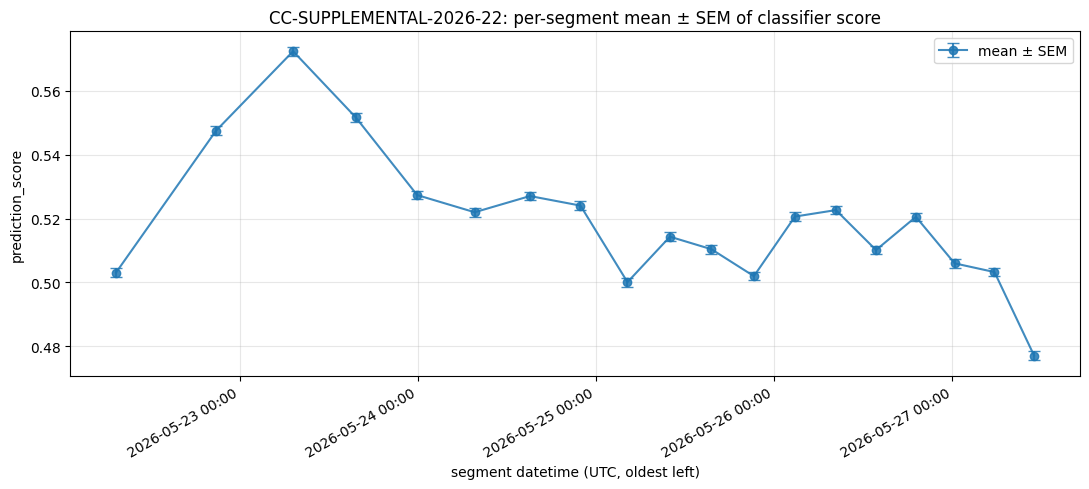

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.errorbar(
    datetimes,
    means,
    yerr=sems,
    fmt="o-",
    capsize=4,
    color="C0",
    ecolor="C0",
    alpha=0.85,
    label="mean ± SEM",
)
ax.set_xlabel("segment datetime (UTC, oldest left)")
ax.set_ylabel("prediction_score")
ax.set_title(f"{FOCUS_NAME}: per-segment mean ± SEM of classifier score")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
fig.autofmt_xdate(rotation=30)
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

## 4. Median with percentile bands over time

Median (p50) is the cleanest single-number tracker of "where the bulk of the segment sits". We add two shaded bands so the distribution *shape* is visible, not just its centre:

- **Inner band — IQR (p25–p75)**: the middle 50 % of the segment. Where the body actually lives.
- **Outer band — p10–p90**: where 80 % of records lie. Captures the tails without being thrown around by individual outliers.

Reading the fan:
- If both bands are **wide and roughly symmetric around the median**, the segment is a genuine mixture.
- If the bands are **clamped to 0 (bottom) or 1 (top)**, the corresponding mode is the dominant one — characteristic of this bimodal classifier.
- A **shrinking IQR over time** with a stable median means the segment is becoming more cleanly bimodal (records pile up at the extremes); a **growing IQR** means more mid-confidence content is appearing.

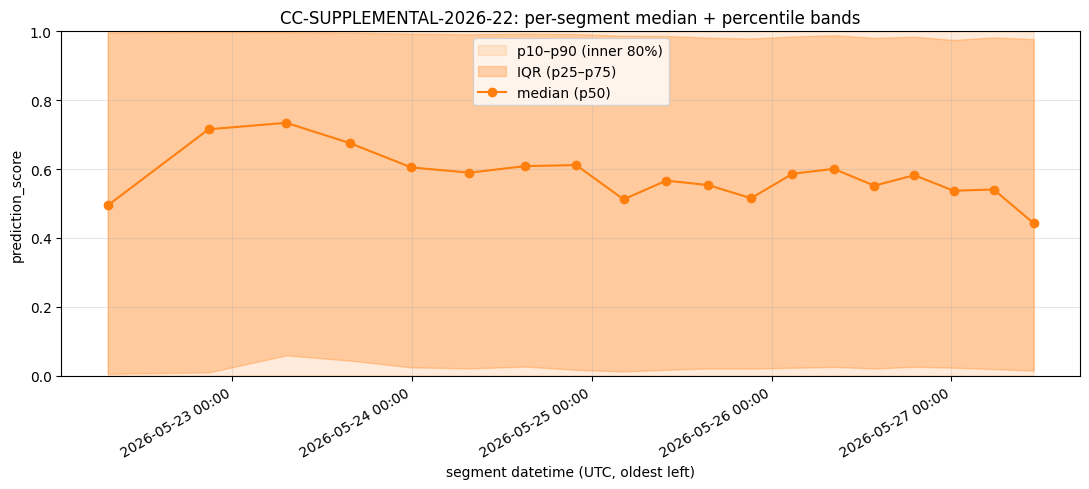

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(datetimes, p10, p90, alpha=0.15, color="C1", label="p10–p90 (inner 80%)")
ax.fill_between(datetimes, p25, p75, alpha=0.30, color="C1", label="IQR (p25–p75)")
ax.plot(datetimes, medians, marker="o", linestyle="-", color="C1", label="median (p50)")
ax.set_ylim(0.0, 1.0)
ax.set_xlabel("segment datetime (UTC, oldest left)")
ax.set_ylabel("prediction_score")
ax.set_title(f"{FOCUS_NAME}: per-segment median + percentile bands")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
fig.autofmt_xdate(rotation=30)
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

## 5. High-confidence rate over time

Mean and median are scalar summaries of a bimodal distribution — useful, but they don't directly answer the downstream question: *how much of each segment will survive a confidence filter?* The **rate** of records crossing a threshold collapses the bimodal scores into one interpretable number per threshold:

- `P(score ≥ 0.5)` — fraction of records the classifier puts on the "science" side of the natural decision boundary.
- `P(score ≥ 0.9)` — fraction high enough that you'd typically trust it without manual review.

Track both: if the `0.9` rate drifts but the `0.5` rate is steady, the segment is staying half-science but losing high-confidence content (or vice versa). The gap between the two lines reflects how much of the segment sits in the mid-confidence band.

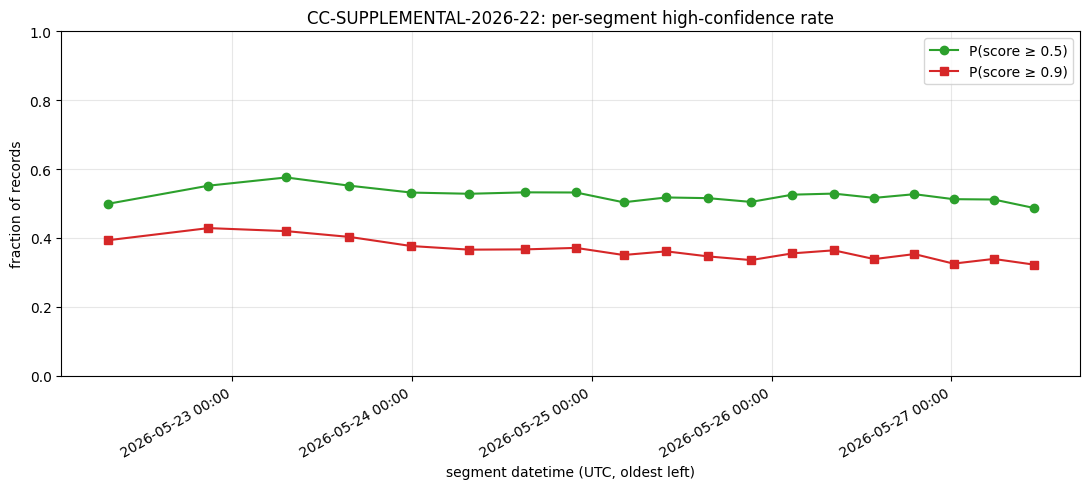

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(datetimes, rate_05, marker="o", linestyle="-", color="C2", label="P(score ≥ 0.5)")
ax.plot(datetimes, rate_09, marker="s", linestyle="-", color="C3", label="P(score ≥ 0.9)")
ax.set_ylim(0.0, 1.0)
ax.set_xlabel("segment datetime (UTC, oldest left)")
ax.set_ylabel("fraction of records")
ax.set_title(f"{FOCUS_NAME}: per-segment high-confidence rate")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
fig.autofmt_xdate(rotation=30)
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

## 6. Mean and median side by side

A consolidated view: mean and median plotted as two lines on the same axes, no error bars or bands. Useful as a quick overall read — if the two lines move together, the bulk of the distribution is shifting with the centre of mass (the typical drift case). If they diverge, the tails are changing weight independently of the bulk: mean drifting above median means the high-confidence tail is gaining mass; mean drifting below median means the low-confidence tail is.

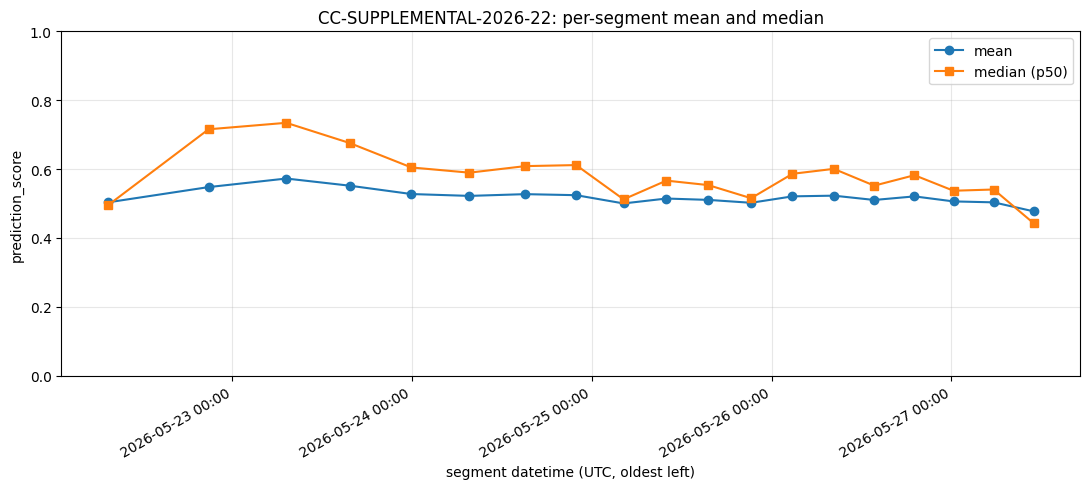

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(datetimes, means, marker="o", linestyle="-", color="C0", label="mean")
ax.plot(datetimes, medians, marker="s", linestyle="-", color="C1", label="median (p50)")
ax.set_ylim(0.0, 1.0)
ax.set_xlabel("segment datetime (UTC, oldest left)")
ax.set_ylabel("prediction_score")
ax.set_title(f"{FOCUS_NAME}: per-segment mean and median")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
fig.autofmt_xdate(rotation=30)
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

## 7. How to read the plots

- **Monotonic trend** (mean, median, or rate moving steadily up or down with time) — systematic drift; worth investigating whether the URL frontier shifted, the seed set changed, or the relative weight of high-/low-quality domains evolved over the crawl.
- **Non-overlapping SEM bars** on the mean plot — the mean difference between those segments is real, not just sampling noise. Overlapping bars say "indistinguishable at this sample size".
- **Mean and median moving together** (Section 6) — the whole distribution is shifting. **Mean and median diverging** — the tails are gaining or losing weight independently of the bulk.
- **Narrowing IQR band** (p25–p75) on the median plot — the segment is becoming more cleanly bimodal (fewer mid-confidence records); a widening band means more mid-confidence content.
- **Widening gap between the `≥ 0.5` and `≥ 0.9` rate lines** — more of the segment is mid-confidence; a narrowing gap means scores are concentrating at the high end.
- **One score-outlier segment** (among the plotted, full-sized segments) — look up the 14-digit token in the WARC fetch logs (`data/gneissweb-science-top-10k/logs/`) for that segment; it may have hit an atypical slice of URLs. Note that *size* outliers (segments with `n < MIN_RECORDS`) are already auto-dropped — see the per-segment table above for which segments were excluded.